# Plot results for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
#IPython.OutputArea.auto_scroll_threshold = 9999;

#from IPython.core.display import display, HTML
#display(HTML("<style>div.output_scroll { height: 440em; }</style>"))

In [2]:
%matplotlib inline
%load_ext autotime

import importlib as imp

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow


import plots
import data_info
import experiment_settings
import mahalanobis
from build_data import build_data

time: 2.1 s (started: 2022-11-04 12:01:21 -06:00)


In [3]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "16 September 2022"

silence_tensorflow()
tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on

DATA_PATH = "data/"
MODEL_PATH = "saved_models/"

time: 390 µs (started: 2022-11-04 12:01:23 -06:00)


In [4]:
plt.style.use("seaborn-white")
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams["figure.dpi"] = 100
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

time: 362 µs (started: 2022-11-04 12:01:23 -06:00)


In [5]:
EXP_NAME = "centered_bivariate_normal_103_EPCP48"
RNG_SEED = 1
TESTING_YEAR = 2018

time: 177 µs (started: 2022-11-04 12:01:23 -06:00)


In [6]:
# GET PREDICTIONS
settings = experiment_settings.get_settings(EXP_NAME)

network_seed = RNG_SEED
settings["rng_seed"] = RNG_SEED
settings["years_test"] = (TESTING_YEAR,)
(
    data_summary,
    x_train,
    onehot_train,
    x_val,
    onehot_val,
    x_test,
    onehot_test,
    x_valtest,
    onehot_valtest,
    df_train,
    df_val,
    df_test,
    df_valtest,
) = build_data(DATA_PATH, settings, verbose=0)

# load the model
model_name = (
    EXP_NAME
    + "_"
    + str(TESTING_YEAR)
    + "_"
    + settings["uncertainty_type"]
    + "_"
    + f"rng_seed_{settings['rng_seed']}"
)
model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)
y_pred_test = model.predict(x_test)
y_pred_valtest = model.predict(x_valtest)
y_pred_train = model.predict(x_train)

time: 606 ms (started: 2022-11-04 12:01:23 -06:00)


# Error diagnostics

In [7]:
error_vec = np.zeros((y_pred_test.shape[0], 2))
for isample in np.arange(0, y_pred_test.shape[0]):
    mu_u, mu_v, sigma_u, sigma_v, rho = (
        y_pred_test[isample, 0],
        y_pred_test[isample, 1],
        y_pred_test[isample, 2],
        y_pred_test[isample, 3],
        y_pred_test[isample, 4],
    )
    cov = np.array(
        [
            [sigma_u**2, rho * sigma_v * sigma_u],
            [rho * sigma_v * sigma_u, sigma_v**2],
        ]
    )
    rv = multivariate_normal([mu_u, mu_v], cov)
    pred_x, pred_y = (rv.mean[0], rv.mean[1])
    error = [pred_x - onehot_test[isample, 0], pred_y - onehot_test[isample, 1]]
    error_vec[isample] = error

rmse = np.sqrt(error_vec[:, 0] ** 2 + error_vec[:, 1] ** 2)
rmse_cons = np.sqrt(onehot_test[:, 0] ** 2 + onehot_test[:, 1] ** 2)
improvement = 100 * (rmse.mean() - rmse_cons.mean()) / rmse_cons.mean()

print("Mean Error Difference")
print("---------------------")
print(str(improvement.round(2)) + "% (negative implies improvement)\n")

print("Mean diagonal error")
print("---------------------")
print(
    rmse.mean().round(3),
    rmse_cons.mean().round(3),
)

print("\nMedian diagonal error")
print("---------------------")
print(np.median(rmse).round(3), np.median(rmse_cons).round(3))

Mean Error Difference
---------------------
-0.0% (negative implies improvement)

Mean diagonal error
---------------------
91.937 91.937

Median diagonal error
---------------------
86.159 86.159
time: 30.3 ms (started: 2022-11-04 12:01:24 -06:00)


# Plot Results

In [8]:
N_COLORS = 50
colors = ("#D95980", "#284E60", "#284E60", "#C3B1E1", "#351F27", "#A9C961")

time: 172 µs (started: 2022-11-04 12:01:24 -06:00)


[205]


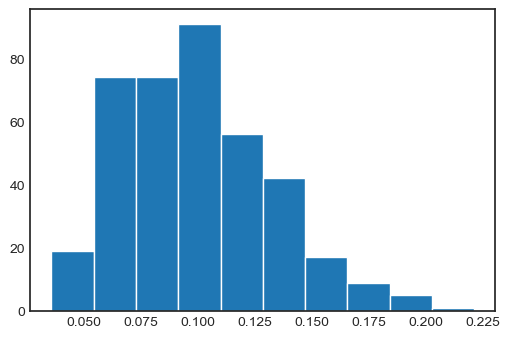

time: 76 ms (started: 2022-11-04 12:01:24 -06:00)


In [10]:
i = np.where(y_pred_test[:, -1] > 0.2)[0]
print(i)
plt.hist(y_pred_test[:, -1])
plt.show()

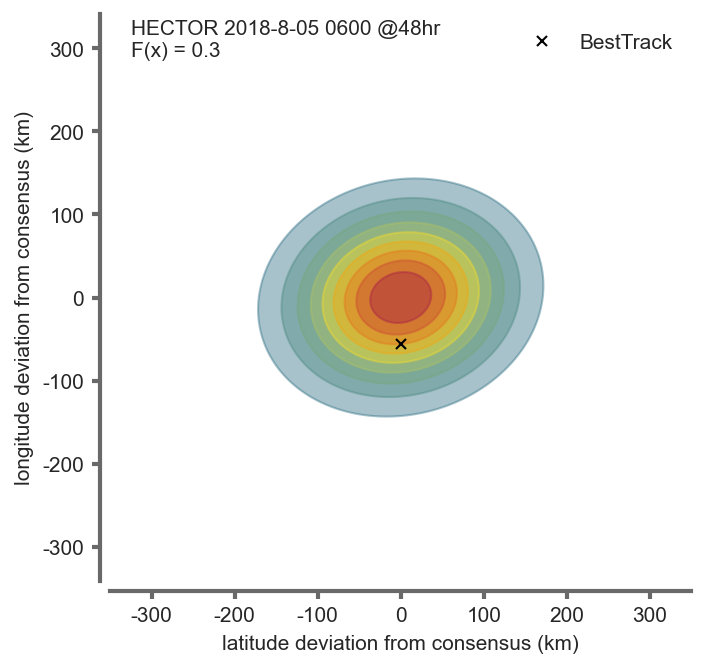

time: 95.4 ms (started: 2022-11-04 12:01:24 -06:00)


In [11]:
imp.reload(mahalanobis)
import cmasher as cmr

COLOR = cmr.take_cmap_colors("cmr.pride", 9, cmap_range=(0.2, 0.8), return_fmt="hex")
# COLOR = cmr.take_cmap_colors('cmr.ember', 9, cmap_range=(0.2, 0.8), return_fmt='hex')


sample_plot = 1
mval = 200
inc = 2

details = data_info.get_storm_details(df_test, sample_plot)
mu_u, mu_v, sigma_u, sigma_v, rho = (
    y_pred_test[sample_plot, 0],
    y_pred_test[sample_plot, 1],
    y_pred_test[sample_plot, 2],
    y_pred_test[sample_plot, 3],
    y_pred_test[sample_plot, 4],
)

fig = plt.figure(figsize=(5, 5), dpi=150)
ax = fig.add_subplot(1,1,1,projection=None)
mahalanobis.plot_cdf(
    mu_u,
    mu_v,
    sigma_u,
    sigma_v,
    rho,
    besttrack_u=onehot_test[sample_plot, 0],
    besttrack_v=onehot_test[sample_plot, 1],
    colors=COLOR,
    data_crs=ax.transData,
)
plt.legend()
cdf_val = mahalanobis.compute_cdf(
    mu_u,
    mu_v,
    sigma_u,
    sigma_v,
    rho,
    onehot_test[sample_plot, 0],
    onehot_test[sample_plot, 1],
)

plt.axis("equal")
plt.yticks(
    np.arange(-300, 500, 100),
    np.arange(-300, 500, 100),
)
plt.xticks(
    np.arange(-300, 500, 100),
    np.arange(-300, 500, 100),
)
plt.xlim(-350, 350)
plt.ylim(-350, 350)
plt.text(-325, 290, details + "\nF(x) = " + str(cdf_val.round(2)))
plt.xlabel("latitude deviation from consensus (km)")
plt.ylabel("longitude deviation from consensus (km)")

plots.format_spines(plt.gca())
plt.show()

0.017670564513939658 0.012371791482634837


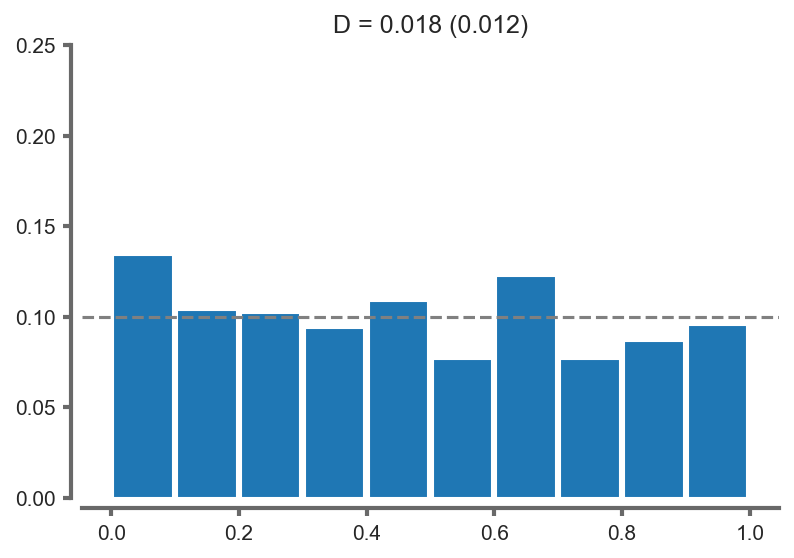

time: 68.9 ms (started: 2022-11-04 12:01:24 -06:00)


In [12]:
# plots.set_plot_rc()
bins = np.linspace(0, 1, 11)
bins_inc = bins[1] - bins[0]

y_data = y_pred_valtest
onehot_data = onehot_valtest

F = mahalanobis.compute_cdf(
    y_data[:, 0],
    y_data[:, 1],
    y_data[:, 2],
    y_data[:, 3],
    y_data[:, 4],
    onehot_data[:, 0],
    onehot_data[:, 1],
)
pit_hist = np.histogram(
    F,
    bins,
    weights=np.ones_like(F) / float(len(F)),
)

B = len(pit_hist[0])
D = np.sqrt(1 / B * np.sum((pit_hist[0] - 1 / B) ** 2))
EDp = np.sqrt((1.0 - 1 / B) / (onehot_data.shape[0] * B))
print(D, EDp)
# F = dist.cdf(onehot_data[:,0])

bin_width = bins_inc / 1.075
bin_add = bins_inc / 2

plt.figure(dpi=150)
plt.bar(
    pit_hist[1][:-1] + bin_add,
    pit_hist[0],
    width=bin_width,
)
plt.axhline(y=0.1, linestyle="--", color="gray")
plt.ylim(0, 0.25)
plt.title("D = " + str(D.round(3)) + " (" + str(EDp.round(3)) + ")")

plots.format_spines(plt.gca())
plt.show()

time: 71.7 ms (started: 2022-11-04 12:01:24 -06:00)
